In [17]:
# 9_Batch_Hedged_Strategy_Analysis

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from OptimalRangeStrategy_FromSimple import OptimalRangeStrategy
from ActiveStrategyFramework import (
    simulate_strategy, generate_simulation_series, analyze_strategy,
    plot_strategy, plot_position_value, plot_pnl_analysis
)
from hedging import apply_delta_hedging

# Global controls
REBALANCE_DAYS_OPTIONS = [1, 3, 7]
INITIAL_USD = 10_000.0
PLOT_DIR = "./plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Pools definition (edit paths/symbols as needed)
POOLS = [
    dict(
        slug="link_weth_03",
        processed_csv="./data/link_weth_03_processed_hourly.csv",
        bigquery_csv="./data/link_weth_03_bigquery.csv",
        token0_symbol="link",
        token1_symbol="eth",
        inverse=False,          # normal pool
        fee_tier=0.003, decimals_0=18, decimals_1=18,
        start=None,             # e.g., "2025-02-20 00:00:00"
        end=None                # e.g., "2025-03-05 00:00:00"
    ),
    dict(
        slug="wtao_weth_1",
        processed_csv="./data/wtao_weth_1_processed_hourly.csv",
        bigquery_csv="./data/wtao_weth_1_bigquery.csv",
        token0_symbol="tao",
        token1_symbol="eth",
        inverse=False,          # normal pool
        fee_tier=0.01, decimals_0=18, decimals_1=18,
        start=None,             # e.g., "2025-02-20 00:00:00"
        end=None                # e.g., "2025-03-05 00:00:00"
    ),
    dict(
        slug="morpho_weth_03",
        processed_csv="./data/morpho_weth_03_processed_hourly.csv",
        bigquery_csv="./data/morpho_weth_03_bigquery.csv",
        token0_symbol="morpho",
        token1_symbol="eth",
        inverse=False,          # normal pool
        fee_tier=0.003, decimals_0=18, decimals_1=18,
        start=None,             # e.g., "2025-02-20 00:00:00"
        end=None                # e.g., "2025-03-05 00:00:00"
    ),
    dict(
        slug="weth_inj_03",
        processed_csv="./data/weth_inj_03_processed_hourly.csv",
        bigquery_csv="./data/weth_inj_03_bigquery.csv",
        token0_symbol="eth",
        token1_symbol="inj",
        inverse=True,           # inverse pool: token0 USD = ETH USD
        fee_tier=0.003, decimals_0=18, decimals_1=18,
        start=None,
        end=None
    ),
]

def load_processed_hourly(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    time_candidates = ['time', 'time_pd', 'timestamp', 'datetime', df.columns[0]]
    col = next(c for c in time_candidates if c in df.columns)
    df['time'] = pd.to_datetime(df[col], utc=True, errors='coerce')
    df = df.dropna(subset=['time']).set_index('time').sort_index()
    return df

def load_swaps(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    time_candidates = ['block_timestamp', 'time', 'timestamp', 'datetime', 'date', df.columns[0]]
    col = next(c for c in time_candidates if c in df.columns)
    df['time'] = pd.to_datetime(df[col], utc=True, errors='coerce')
    df = df.dropna(subset=['time']).set_index('time').sort_index()
    return df

def load_vol_corr_or_none(slug: str) -> pd.DataFrame | None:
    path = f"./data/pool_volatility_correlation/{slug}_volatility_correlation.csv"
    if not os.path.exists(path):
        return None
    v = pd.read_csv(path)
    if 'datetime' in v.columns:
        v['datetime'] = pd.to_datetime(v['datetime'], utc=True, errors='coerce')
        v = v.dropna(subset=['datetime']).set_index('datetime').sort_index()
    else:
        v[v.columns[0]] = pd.to_datetime(v[v.columns[0]], utc=True, errors='coerce')
        v = v.dropna(subset=[v.columns[0]]).set_index(v.columns[0]).sort_index()
    return v[['cross_price_volatility', 'correlation']]

In [18]:
def _annotate_plot(fig, title, y_label=None, legend_map=None):
    ax = fig.axes[0]
    ax.set_title(title)
    if y_label:
        ax.set_ylabel(y_label)
    if legend_map:
        leg = ax.get_legend()
        if leg:
            for t in leg.texts:
                if t.get_text() in legend_map:
                    t.set_text(legend_map[t.get_text()])
    return fig


def run_pool_horizon(pool, rebalance_days, start_ts=None, end_ts=None, plot_dir=PLOT_DIR):
    os.makedirs(plot_dir, exist_ok=True)

    # Load data
    dfp = load_processed_hourly(pool['processed_csv'])
    dfs = load_swaps(pool['bigquery_csv'])
    vol_df = load_vol_corr_or_none(pool['slug'])

    # Apply time window
    if start_ts is not None:
        start_ts = pd.Timestamp(start_ts, tz='UTC')
    if end_ts is not None:
        end_ts = pd.Timestamp(end_ts, tz='UTC')
    if start_ts or end_ts:
        dfp = dfp.loc[start_ts:end_ts]
        dfs = dfs.loc[start_ts:end_ts]
        if vol_df is not None:
            vol_df = vol_df.loc[start_ts:end_ts]

    # Inputs
    price_data = dfp['quotePrice'].astype(float)
    swaps_full = dfs

    # token0 USD data selection; inverse pool uses ETH USD for token0
    token0_usd_col = 'eth_usd_price' if pool['inverse'] else 'token1_usd_price'
    assert token0_usd_col in dfp.columns, f"Missing {token0_usd_col} in processed hourly file"
    token_0_usd_data = dfp[[token0_usd_col]].rename(columns={token0_usd_col: 'quotePrice'})

    # Vol/corr if available
    vol_slice = None
    if vol_df is not None and not price_data.empty:
        vol_slice = vol_df.loc[price_data.index.min():price_data.index.max()]

    # Strategy
    strategy = OptimalRangeStrategy(
        volatility_data=vol_slice,
        rebalance_days=rebalance_days,
        alpha_range=(1.02, 2.0),
        alpha_steps=50,
        days_in_year=365
    )

    # Initial 50/50 USD at t0
    t0 = price_data.index[0]
    p_t0 = float(price_data.iloc[0])
    p0usd_t0 = float(token_0_usd_data.iloc[0, 0])
    token1_usd_t0 = p0usd_t0 / p_t0
    amt0 = (INITIAL_USD / 2.0) / p0usd_t0
    amt1 = (INITIAL_USD / 2.0) / token1_usd_t0

    sims = simulate_strategy(
        price_data=price_data,
        swap_data=swaps_full,
        strategy_in=strategy,
        liquidity_in_0=float(amt0),
        liquidity_in_1=float(amt1),
        fee_tier=pool.get('fee_tier', 0.003),
        decimals_0=pool.get('decimals_0', 18),
        decimals_1=pool.get('decimals_1', 18),
        token_0_usd_data=token_0_usd_data
    )
    res = generate_simulation_series(sims, strategy_in=strategy, token_0_usd_data=token_0_usd_data)

    # Full hedge (both tokens), reporting in USD
    res_full = apply_delta_hedging(
        strategy_df=res,
        token0_symbol_slug=pool['token0_symbol'],
        token1_symbol_slug=pool['token1_symbol'],
        price_source='usd',
        token0_usd_col='price_0_usd',
        token1_usd_col=None,         # derive via token0_usd / quote price
        quote_price_col='price',
        hedge_only='both',
        reporting_unit='usd'
    )

    # Token0-only hedge, reporting in token1 units
    res_t1 = apply_delta_hedging(
        strategy_df=res,
        token0_symbol_slug=pool['token0_symbol'],
        token1_symbol_slug=pool['token1_symbol'],
        price_source='usd',
        token0_usd_col='price_0_usd',
        token1_usd_col=None,
        quote_price_col='price',
        hedge_only='token0',
        reporting_unit='token1'
    )

    # File/labels
    fn_stub = f"{pool['slug']}_reb{rebalance_days}d"
    pool_name = pool['slug'].upper().replace('_', '-')

    # 1) Price/Range
    fig1 = plot_strategy(res, f"{pool_name} Price")
    fig1 = _annotate_plot(
        fig1,
        f"{pool_name} | Rebal {rebalance_days}D | Price & Ranges",
        y_label=f"{pool['token0_symbol'].upper()}/{pool['token1_symbol'].upper()} Price",
    )
    fig1.savefig(os.path.join(plot_dir, f"{fn_stub}_price.png"), dpi=150, bbox_inches='tight'); plt.close(fig1)

    # 2) LP vs HOLD (USD)
    fig2 = plot_position_value(res_full)
    fig2 = _annotate_plot(
        fig2,
        f"{pool_name} | Rebal {rebalance_days}D | LP vs HOLD (USD)",
        y_label="Value (USD)",
        legend_map={
            "Value of LP Position": "LP Value (USD)",
            "Value of Holding":     "HOLD Value (USD)",
            "Hedge Value (short)":  "Hedge Value (USD)",
            "LP + Hedge Value":     "LP + Hedge Value (USD)"
        }
    )
    fig2.savefig(os.path.join(plot_dir, f"{fn_stub}_lp_vs_hold.png"), dpi=150, bbox_inches='tight'); plt.close(fig2)

    # 3) PnL analysis (USD)
    fig3 = plot_pnl_analysis(res_full)
    fig3 = _annotate_plot(
        fig3,
        f"{pool_name} | Rebal {rebalance_days}D | PnL Analysis (USD)",
        y_label="PnL (USD)",
        legend_map={
            "LP PnL":                    "LP PnL (USD)",
            "Hold PnL":                  "HOLD PnL (USD)",
            "Hedge Total PnL":           "Hedge Total PnL (USD)",
            "Combined PnL (LP + Hedge)": "Combined (LP+Hedge) (USD)"
        }
    )
    fig3.savefig(os.path.join(plot_dir, f"{fn_stub}_pnl_usd.png"), dpi=150, bbox_inches='tight'); plt.close(fig3)

    # 4) Token1 PnL (token0-only hedge)
    df = res_t1.sort_values('time_pd')
    x = df['time_pd'].to_numpy()
    init_t1 = float(df['value_position_token1'].iloc[0])
    lp_pnl_t1    = (df['value_position_token1'] - init_t1)
    hold_pnl_t1  = (df['value_hold_token1']     - init_t1)
    hedge_pnl_t1 = df['hedge_realized_pnl_total_token1'].fillna(0.0) + df['hedge_unrealized_pnl_total_token1'].fillna(0.0)
    combined_t1  = (lp_pnl_t1 + hedge_pnl_t1)

    fig4, ax = plt.subplots(figsize=(10,4))
    ax.plot(x, lp_pnl_t1.to_numpy().ravel(),    color='red',    lw=2, label='LP PnL (token1)')
    ax.plot(x, hold_pnl_t1.to_numpy().ravel(),  color='blue',   lw=2, label='HOLD PnL (token1)')
    ax.plot(x, hedge_pnl_t1.to_numpy().ravel(), color='green',  lw=2, label='Hedge Total PnL (token1)')
    ax.plot(x, combined_t1.to_numpy().ravel(),  color='purple', lw=2, label='Combined (token1)')
    ax.set_title(f"{pool_name} | Rebal {rebalance_days}D | PnL (token1) | Hedge: token0-only")
    ax.set_xlabel('Date'); ax.set_ylabel('PnL (token1)'); ax.grid(True, alpha=0.3); ax.legend(loc='best')
    plt.tight_layout()
    fig4.savefig(os.path.join(plot_dir, f"{fn_stub}_pnl_token1.png"), dpi=150, bbox_inches='tight'); plt.close(fig4)

    # Stats (USD)
    base_stats = analyze_strategy(res, 'H')
    full_stats = analyze_strategy(res_full, 'H')

    # Token1 stats (Sharpe on combined token1 PnL)
    ann = (365*24) ** 0.5
    init_token1_val = float(df['value_position_token1'].iloc[0])
    combined_token1_value = init_token1_val + combined_t1.astype(float)
    vol_t1 = float(np.sqrt(combined_token1_value.pct_change().var()) * ann)
    net_return_t1 = float((combined_token1_value.iloc[-1] / init_token1_val) - 1.0)
    days = max((df['time_pd'].iloc[-1] - df['time_pd'].iloc[0]).days, 1)
    net_apr_t1 = float(net_return_t1 * 365 / days)
    sharpe_t1 = float(net_apr_t1 / vol_t1) if vol_t1 not in [0.0, np.nan] else np.nan
    token1_stats = dict(
        net_return_token1=net_return_t1,
        net_apr_token1=net_apr_t1,
        volatility_token1=vol_t1,
        sharpe_ratio_token1=sharpe_t1
    )

    # Save CSVs
    res_full.to_csv(f"./results_{fn_stub}_fullhedge.csv", index=False)
    res_t1.to_csv(f"./results_{fn_stub}_token1hedge.csv", index=False)

    return dict(
        pool=pool['slug'],
        rebalance_days=rebalance_days,
        base_stats=base_stats,
        full_stats=full_stats,
        token1_stats=token1_stats
    )

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy_results.append(StrategyObservation(price_data.index[i], price_data[i], strategy_in,
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:115: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strategy_results.append(StrategyObservation(price_data.index[i], price_data[i], strategy_in,


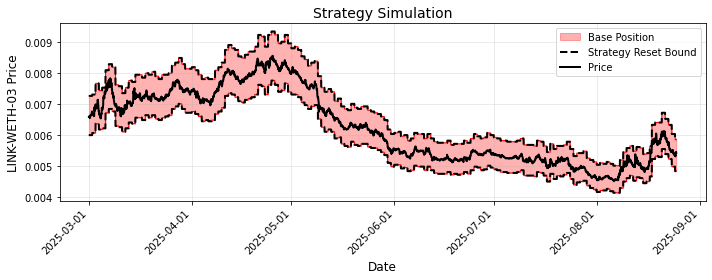

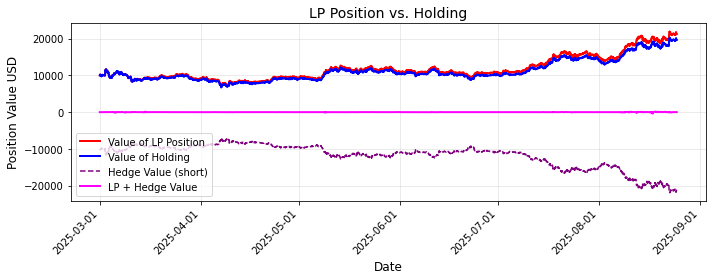

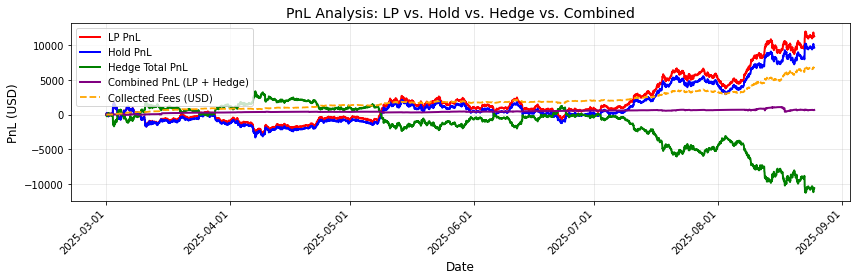

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


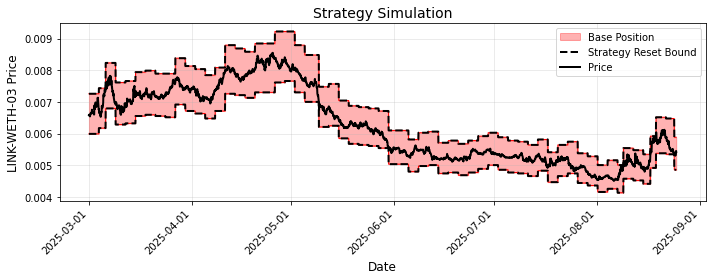

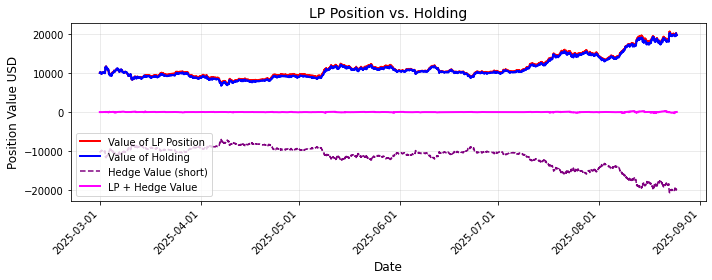

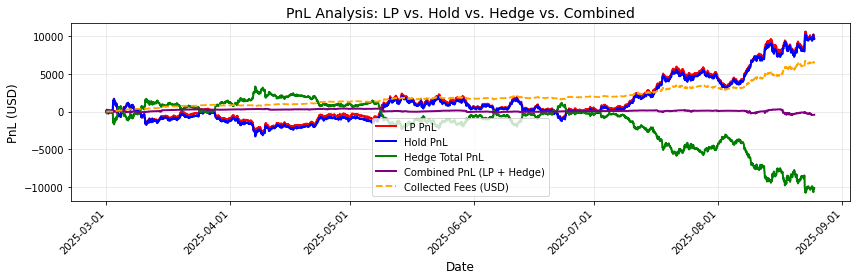

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


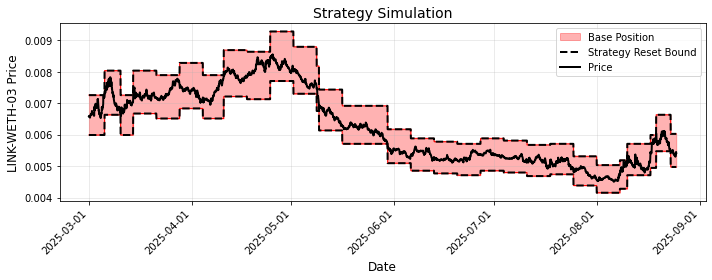

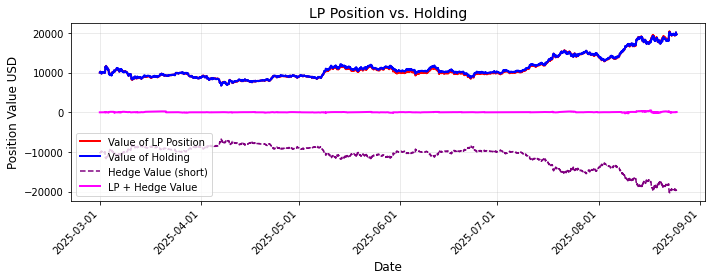

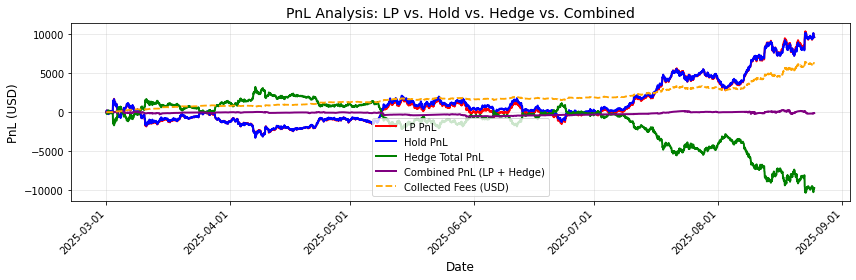

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


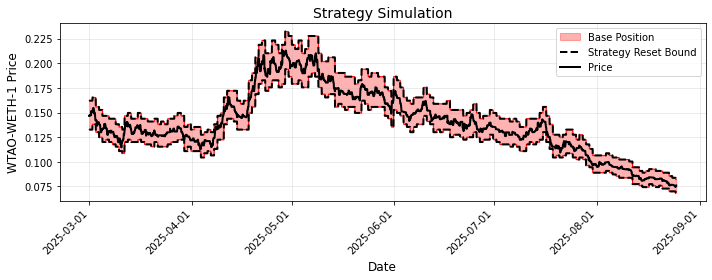

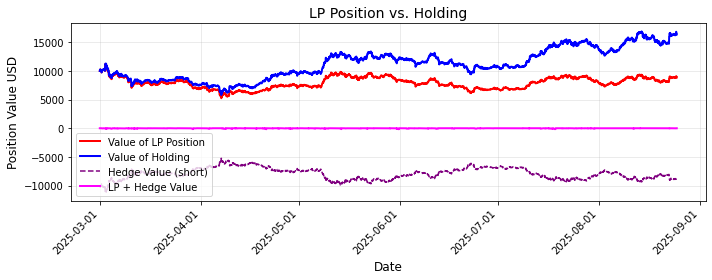

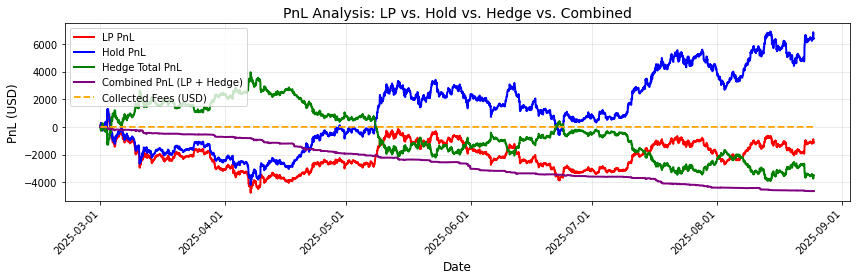

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


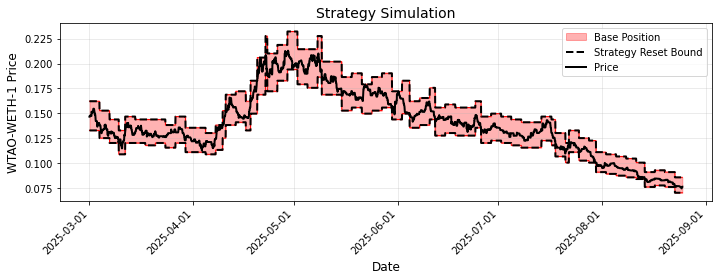

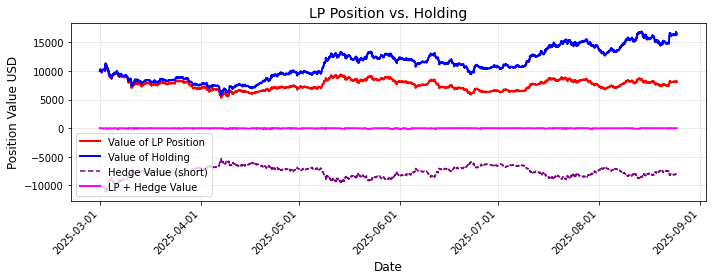

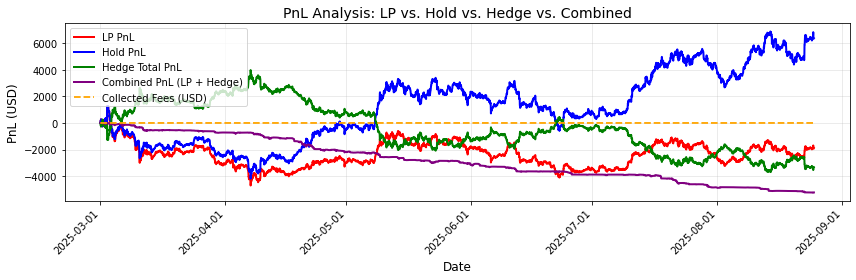

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


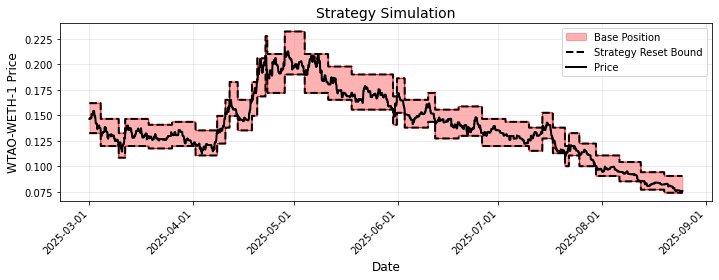

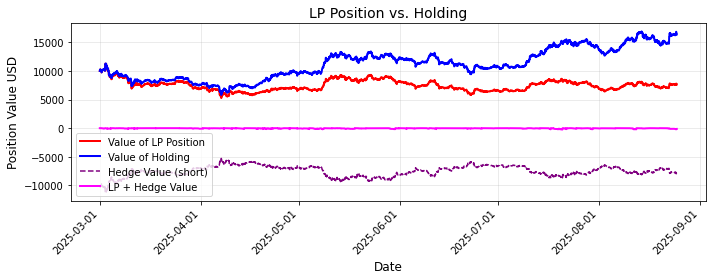

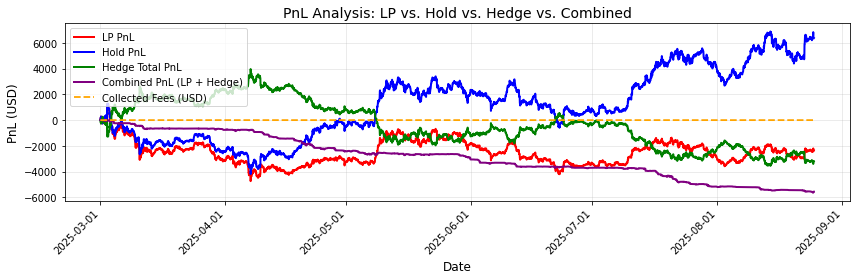

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


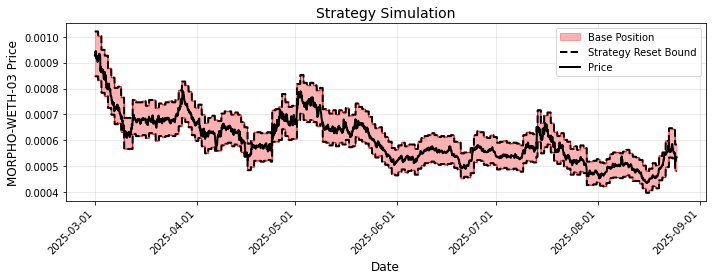

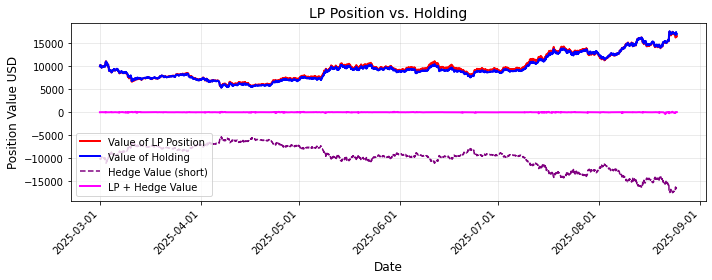

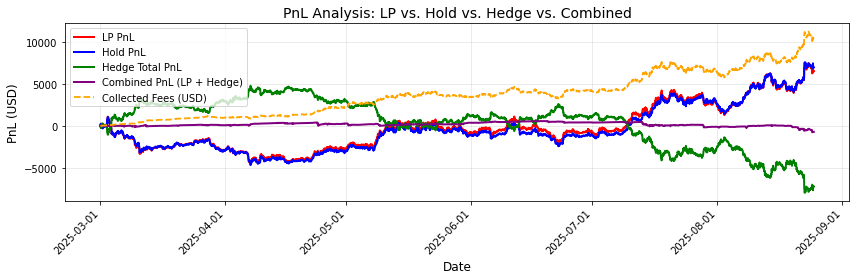

/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:250: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  net_apr                 = float((strategy_last_obs['value_position_usd']/initial_position_value - 1) * 365 / days_strategy)
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:255: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_apr'        : float((strategy_last_obs['cum_fees_usd']/initial_position_value) * 365 / days_strategy),
/Users/nicolaschiavo/Dev/tesi/univ3-strategies/ActiveStrategyFramework.py:256: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  'gross_fee_return'     : float(strategy_last_obs['cum_fees_usd']/initial_position_value),


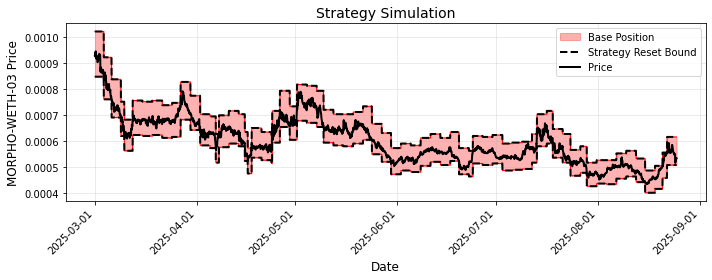

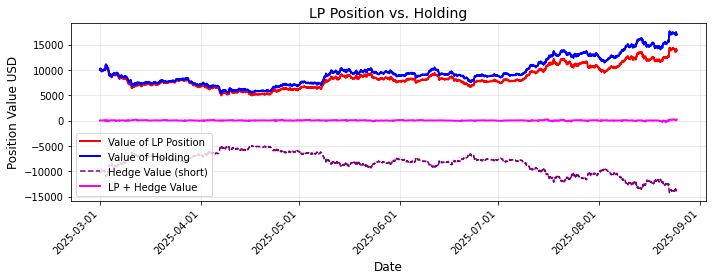

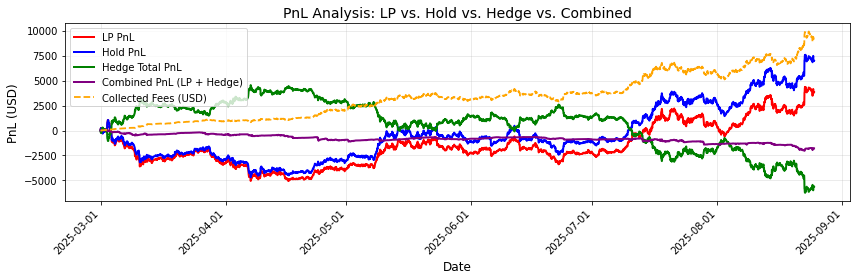

In [ ]:
# Select a global window (UTC) or leave as None to use full range
GLOBAL_START = "2025-03-01 00:00:00"
GLOBAL_END   = "2025-08-25 00:00:00"

rows = []
for pool in POOLS:
    """ start_ts = pool.get('start', GLOBAL_START)
    end_ts   = pool.get('end', GLOBAL_END) """
    start_ts = GLOBAL_START
    end_ts   = GLOBAL_END
    for T in REBALANCE_DAYS_OPTIONS:
        try:
            row = run_pool_horizon(pool, T, start_ts=start_ts, end_ts=end_ts)
            flat = dict(pool=row['pool'], rebalance_days=row['rebalance_days'])
            flat.update({f"base_{k}": v for k, v in row['base_stats'].items()})
            flat.update({f"full_{k}": v for k, v in row['full_stats'].items()})
            flat.update(row['token1_stats'])  # token1 Sharpe etc.
            rows.append(flat)
        except Exception as e:
            print(f"Failed: {pool['slug']} @ {T}D -> {e}")

report = pd.DataFrame(rows).sort_values(['pool','rebalance_days']).reset_index(drop=True)
display(report)
report.to_csv("./batch_strategy_report.csv", index=False)
print("Saved batch_strategy_report.csv")